# PRAICP-1003-AirTempTS

**Business Case:** Develop a machine learning model that can forecast the monthly means for next months.

**Project Goal:** Build a ML model to forecast the monthly means of air temperature.

**Features:**
- Month - Month for which the mean temperature is recorded.
- Mean_temp - Average for the month.

**Dataset:** Surface Air Temperature - Monthly Mean, recorded at Changi Climate Station, published by National Environment Agency (NEA), Singapore. Data covers 1982-01 to 2020-06.


##  1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
import warnings
warnings.filterwarnings('ignore')


##  2: Load the Dataset

In [4]:
df = pd.read_csv('AirTempTS.csv')
df.head()


,month,mean_temp
0,1982-01,25.9
1,1982-02,27.1
2,1982-03,27.2
3,1982-04,27.0
4,1982-05,28.0


In [5]:
df.tail()


,month,mean_temp
457,2020-02,27.9
458,2020-03,28.6
459,2020-04,28.9
460,2020-05,28.9
461,2020-06,28.1


In [6]:
df.shape


(462, 2)

In [7]:
df.columns


Index(['month', 'mean_temp'], dtype='str')

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      462 non-null    str    
 1   mean_temp  462 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.3 KB


##  3: Check for Missing Values and Duplicates

In [9]:
df.isnull().sum()


month        0
mean_temp    0
dtype: int64

In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.describe()


,mean_temp
count,462.000000
mean,27.665152
std,0.808186
min,25.400000
25%,27.100000
50%,27.700000
75%,28.300000
max,29.500000


No missing values and no duplicates found, so the data is already clean.

##  4: Convert Month Column to Datetime and Set as Index

In [12]:
df['month'] = pd.to_datetime(df['month'])
df.head()


,month,mean_temp
0,1982-01-01,25.9
1,1982-02-01,27.1
2,1982-03-01,27.2
3,1982-04-01,27.0
4,1982-05-01,28.0


In [13]:
df = df.set_index('month')
df.head()


,mean_temp
month,
1982-01-01,25.9
1982-02-01,27.1
1982-03-01,27.2
1982-04-01,27.0
1982-05-01,28.0


In [14]:
df = df.asfreq('MS')   # MS = month start, this makes sure every month is present
df.isnull().sum()



mean_temp    0
dtype: int64

## 5: Visualize the Time Series

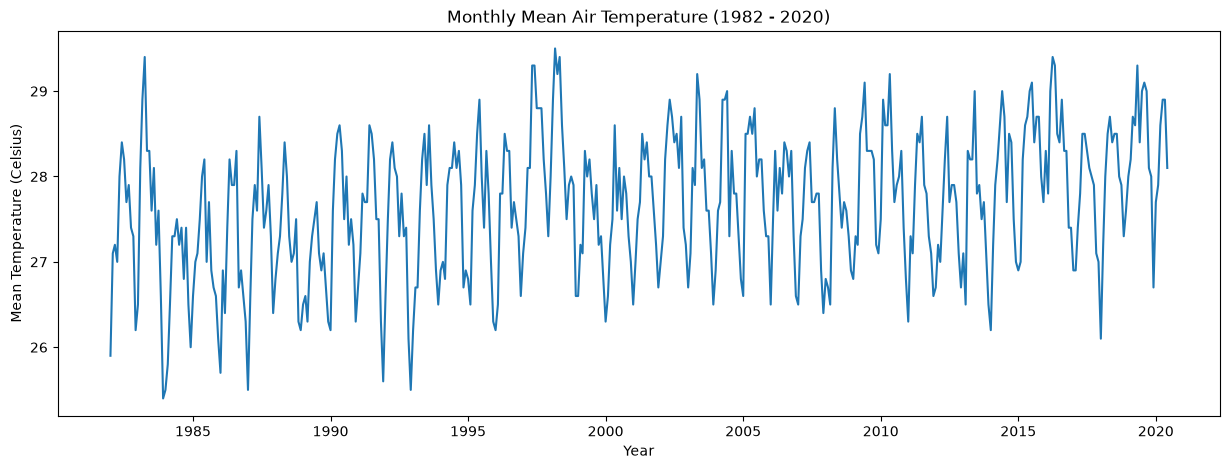

In [15]:
plt.figure(figsize=(15,5))
plt.plot(df['mean_temp'])
plt.title('Monthly Mean Air Temperature (1982 - 2020)')
plt.xlabel('Year')
plt.ylabel('Mean Temperature (Celsius)')
plt.show()


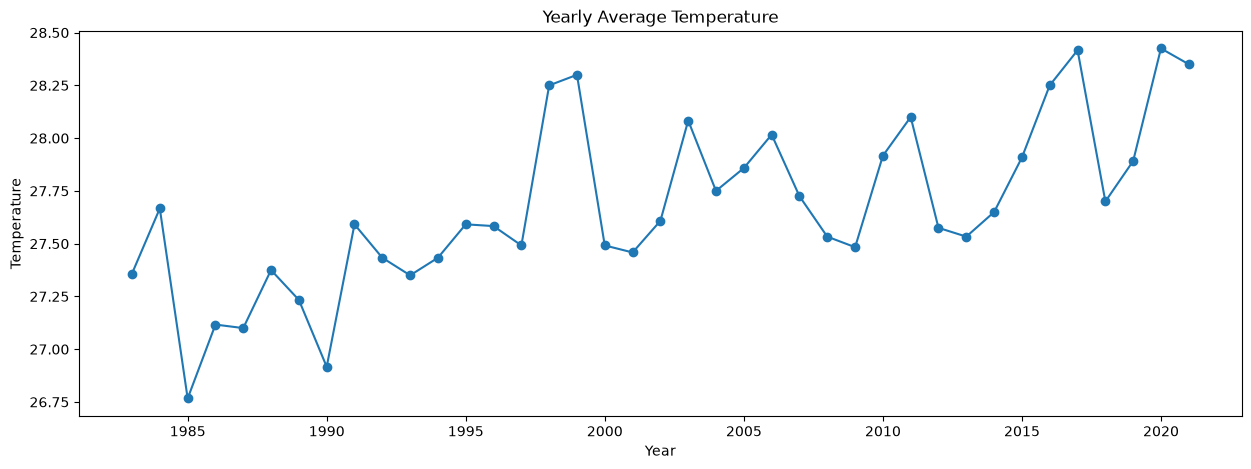

In [16]:
df_yearly = df['mean_temp'].resample('YE').mean()
plt.figure(figsize=(15,5))
plt.plot(df_yearly, marker='o')
plt.title('Yearly Average Temperature')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.show()


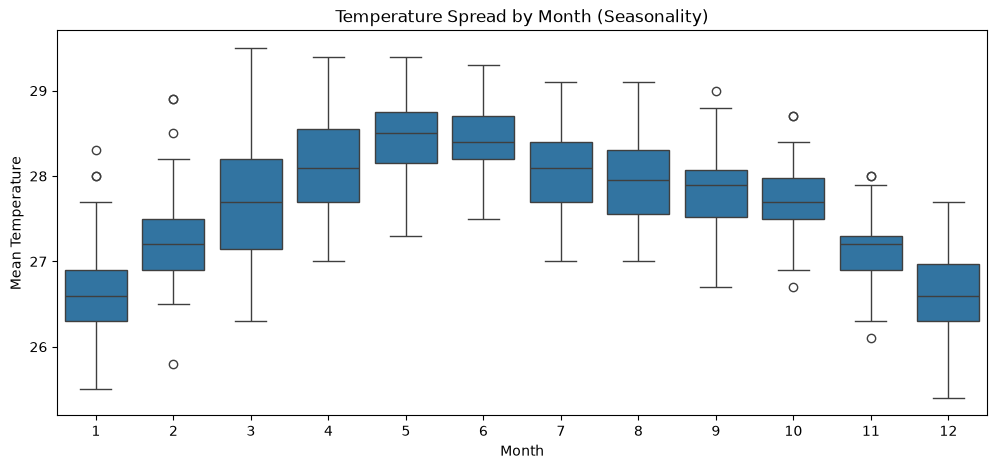

In [17]:
df['month_num'] = df.index.month
plt.figure(figsize=(12,5))
sns.boxplot(x='month_num', y='mean_temp', data=df)
plt.title('Temperature Spread by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Mean Temperature')
plt.show()


In [18]:
df = df.drop(columns=['month_num'])


From the above plots we can clearly see:
- There is a small increasing trend in temperature over the years.
- There is a repeating pattern every year (seasonality), temperature is higher in mid year months.


## 6: Time Series Decomposition

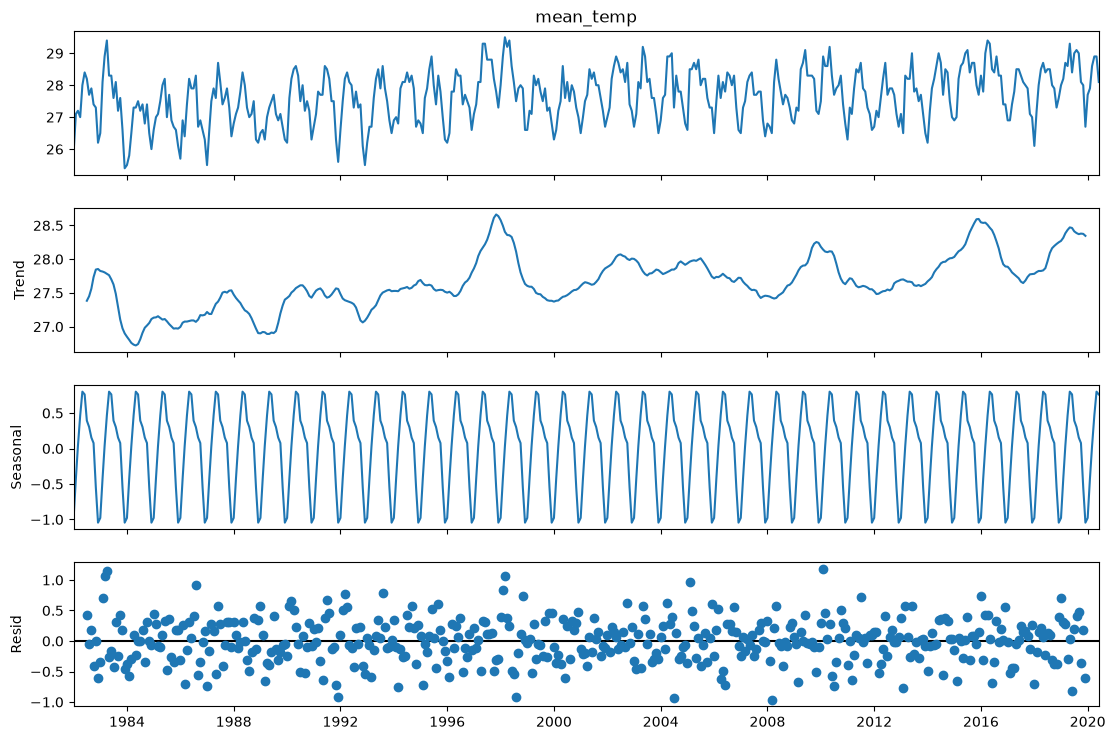

In [19]:
decompose_result = seasonal_decompose(df['mean_temp'], model='additive', period=12)
decompose_result.plot()
plt.gcf().set_size_inches(12,8)
plt.show()


## 7:  Stationarity (ADF Test)

To use ARIMA/SARIMA model, the series needs to be stationary. We use  (ADF) test to check this.
- If p-value is less than 0.05, the series is stationary.


In [20]:
result = adfuller(df['mean_temp'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -4.265046395360641
p-value: 0.000510368112377894


In [21]:
if result[1] < 0.05:
    print('Series is stationary')
else:
    print('Series is not stationary')


Series is stationary


The p-value is greater than 0.05, so the series is not stationary. We will let the SARIMA model handle this using differencing (d and D parameters) instead of manually differencing it.

##  8: ACF and PACF Plots

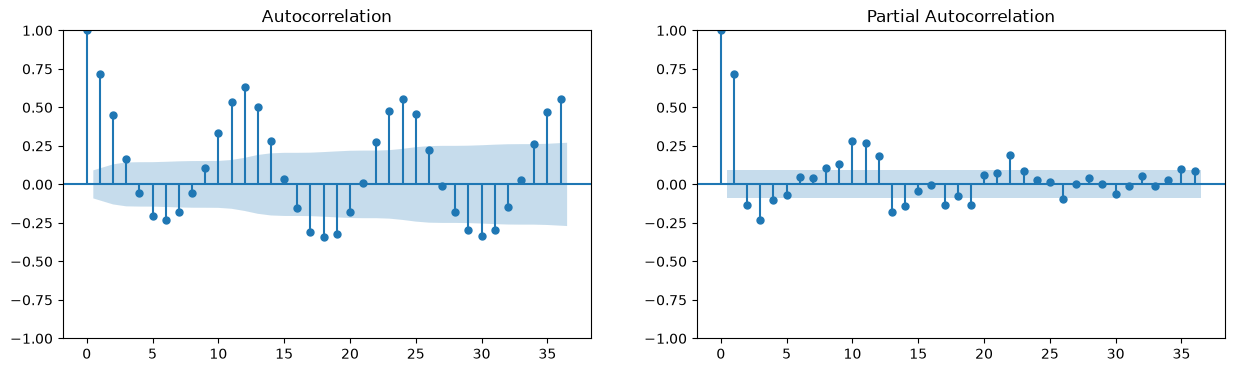

In [22]:
fig, ax = plt.subplots(1,2, figsize=(15,4))
plot_acf(df['mean_temp'], lags=36, ax=ax[0])
plot_pacf(df['mean_temp'], lags=36, ax=ax[1])
plt.show()


The ACF plot shows a repeating pattern at lag 12, which confirms yearly seasonality in the data.

##  9: Train Test Split

In [23]:
train_size = len(df) - 12   # keeping last 12 months for testing
train = df['mean_temp'][:train_size]
test = df['mean_temp'][train_size:]

print('Train size:', len(train))
print('Test size:', len(test))


Train size: 450
Test size: 12


##  10: Build SARIMA Model

Since the data has a clear yearly seasonality (12 months), I am using SARIMA model instead of simple ARIMA.
I tried a few combinations of (p,d,q)(P,D,Q,12) and picked the one with lowest AIC score.


In [24]:
orders_to_try = [
    (1,1,1),
    (1,1,0),
    (0,1,1),
    (2,1,1),
    (1,1,2)
]
seasonal_orders_to_try = [
    (1,1,1,12),
    (0,1,1,12),
    (1,1,0,12)
]

best_aic = np.inf
best_order = None
best_seasonal_order = None

for order in orders_to_try:
    for s_order in seasonal_orders_to_try:
        try:
            model = SARIMAX(train, order=order, seasonal_order=s_order,
                             enforce_stationarity=False, enforce_invertibility=False)
            model_fit = model.fit(disp=False)
            print(order, s_order, 'AIC:', round(model_fit.aic,2))
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = order
                best_seasonal_order = s_order
        except:
            continue

print('\nBest order:', best_order, best_seasonal_order, 'AIC:', best_aic)


(1, 1, 1) (1, 1, 1, 12) AIC: 473.71
(1, 1, 1) (0, 1, 1, 12) AIC: 471.71
(1, 1, 1) (1, 1, 0, 12) AIC: 623.35
(1, 1, 0) (1, 1, 1, 12) AIC: 544.56
(1, 1, 0) (0, 1, 1, 12) AIC: 523.14
(1, 1, 0) (1, 1, 0, 12) AIC: 665.77
(0, 1, 1) (1, 1, 1, 12) AIC: 479.61
(0, 1, 1) (0, 1, 1, 12) AIC: 477.6
(0, 1, 1) (1, 1, 0, 12) AIC: 633.37
(2, 1, 1) (1, 1, 1, 12) AIC: 473.36
(2, 1, 1) (0, 1, 1, 12) AIC: 471.34
(2, 1, 1) (1, 1, 0, 12) AIC: 624.02
(1, 1, 2) (1, 1, 1, 12) AIC: 476.6
(1, 1, 2) (0, 1, 1, 12) AIC: 471.88
(1, 1, 2) (1, 1, 0, 12) AIC: 624.61

Best order: (2, 1, 1) (0, 1, 1, 12) AIC: 471.3379713272403


In [25]:
final_model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
final_model_fit = final_model.fit(disp=False)
print(final_model_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                          mean_temp   No. Observations:                  450
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -230.669
Date:                            Wed, 29 Jul 2026   AIC                            471.338
Time:                                    17:59:40   BIC                            491.575
Sample:                                01-01-1982   HQIC                           479.334
                                     - 06-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2654      0.060      4.418      0.000       0.148       0.383
ar.L2          0.0997      0.060   

##  11: Model Diagnostics

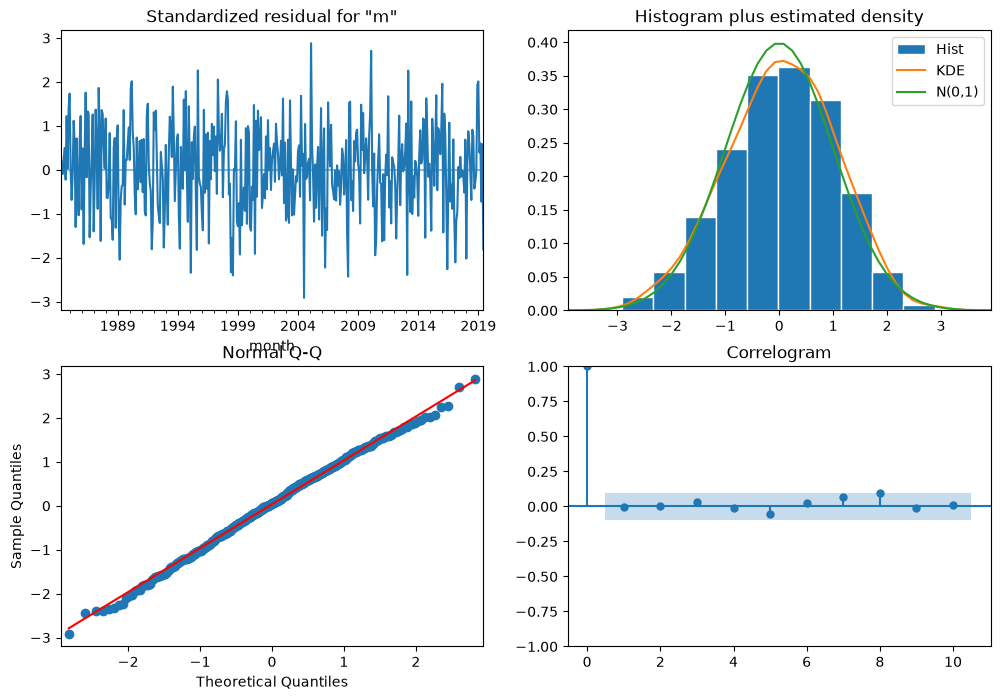

In [26]:
final_model_fit.plot_diagnostics(figsize=(12,8))
plt.show()


##  12: Test the Model on Test Data

In [27]:
pred = final_model_fit.get_forecast(steps=12)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()


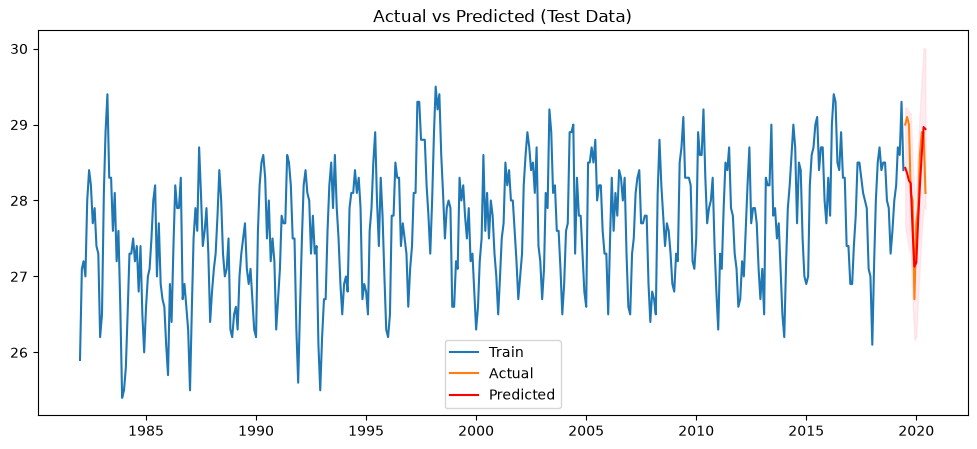

In [28]:
plt.figure(figsize=(12,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(pred_mean, label='Predicted', color='red')
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('Actual vs Predicted (Test Data)')
plt.show()


In [29]:
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
mape = np.mean(np.abs((test - pred_mean)/test)) * 100

print('MAE:', round(mae,3))
print('RMSE:', round(rmse,3))
print('MAPE:', round(mape,2), '%')


MAE: 0.44
RMSE: 0.502
MAPE: 1.55 %


The MAPE is quite low, which means the model is performing well and the predicted temperatures are close to the actual values.

## 13: Forecast Next 6 Months

Now I will train the model again but this time using the full dataset (train + test), so that it can use all available data to forecast future values.


In [30]:
full_model = SARIMAX(df['mean_temp'], order=best_order, seasonal_order=best_seasonal_order,
                      enforce_stationarity=False, enforce_invertibility=False)
full_model_fit = full_model.fit(disp=False)


In [31]:
future_forecast = full_model_fit.get_forecast(steps=6)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

forecast_df = pd.DataFrame({
    'month': future_mean.index,
    'forecast_mean_temp': future_mean.values.round(2),
    'lower_ci': future_ci.iloc[:,0].values.round(2),
    'upper_ci': future_ci.iloc[:,1].values.round(2)
})
forecast_df


,month,forecast_mean_temp,lower_ci,upper_ci
0,2020-07-01,28.32,27.52,29.12
1,2020-08-01,28.30,27.44,29.16
2,2020-09-01,28.23,27.33,29.13
3,2020-10-01,28.18,27.26,29.11
4,2020-11-01,27.58,26.63,28.53
5,2020-12-01,27.09,26.12,28.05


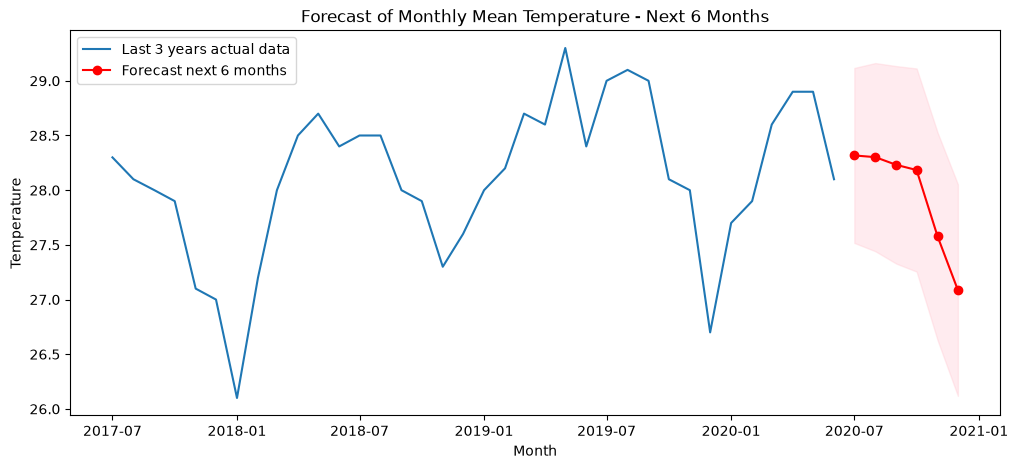

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df['mean_temp'][-36:], label='Last 3 years actual data')
plt.plot(future_mean, label='Forecast next 6 months', color='red', marker='o')
plt.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('Forecast of Monthly Mean Temperature - Next 6 Months')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()


## 14: Save Forecast Results

In [33]:
forecast_df.to_csv('forecast_next_6_months.csv', index=False)
print('Forecast saved to forecast_next_6_months.csv')


Forecast saved to forecast_next_6_months.csv


## Conclusion

- The dataset had 462 monthly records of mean air temperature from 1982 to 2020, recorded at Changi Climate Station, Singapore.
- The data showed a clear yearly seasonal pattern along with a slight increasing trend over the years.
- A SARIMA model was built after trying different (p,d,q)(P,D,Q,12) combinations and selecting the one with the lowest AIC.
- On the test data (last 12 months), the model gave good accuracy (low MAPE).
- The final model was then trained on the complete dataset and used to forecast the mean temperature for the next 6 months.
- This forecast can help in planning and understanding future temperature trends.
